In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

In [15]:
x,y = make_classification(n_samples=100, n_features=2, n_informative=1, random_state=31, n_classes=2, n_clusters_per_class=1, n_redundant=0, class_sep=0.3)

In [16]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

<Axes: >

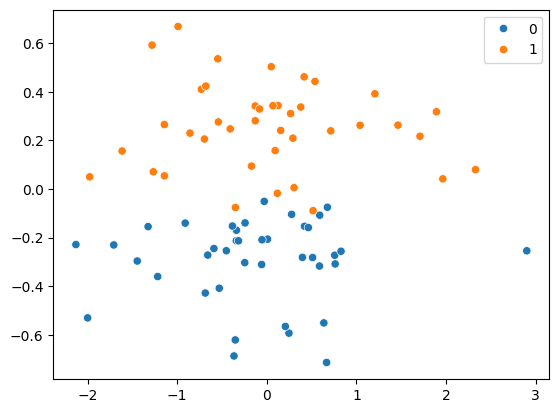

In [17]:
import seaborn as sns
sns.scatterplot(x=x_train[:,0], y=x_train[:,1], hue=y_train)

In [18]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import Sequential

In [21]:
model = Sequential([
    layers.Dense(2, activation='relu', input_shape=(2,)),
    layers.Dense(1, activation='sigmoid')
])

f:\Python\Deep-Learning-and-Computer-vision\deepenv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [23]:
model.get_weights()

[array([[ 0.7358061 , -1.0883108 ],
        [ 0.25515008, -1.119148  ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-0.62696946],
        [ 0.34812248]], dtype=float32),
 array([0.], dtype=float32)]

In [24]:
intial_weights = model.get_weights()

In [25]:
import numpy as np


In [26]:
intial_weights[0]

array([[ 0.7358061 , -1.0883108 ],
       [ 0.25515008, -1.119148  ]], dtype=float32)

In [27]:
intial_weights[0] = np.zeros(model.get_weights()[0].shape)
intial_weights[1] = np.zeros(model.get_weights()[1].shape)
intial_weights[2] = np.zeros(model.get_weights()[2].shape)
intial_weights[3] = np.zeros(model.get_weights()[3].shape)

In [29]:
model.set_weights(intial_weights)

In [30]:
model.get_weights()

[array([[0., 0.],
        [0., 0.]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.],
        [0.]], dtype=float32),
 array([0.], dtype=float32)]

In [31]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=100, batch_size=10, validation_split=0.2)


Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5000 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss:

In [33]:
model.get_weights() #since starting weights are all zeros, the model is not able to learn anything and the weights remain the same after training. same is the case with bias weights. The model is not able to learn anything and the weights remain the same after training. Both relu and tanh have the same output.

[array([[0., 0.],
        [0., 0.]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.],
        [0.]], dtype=float32),
 array([-0.00489773], dtype=float32)]

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 7s 673us/step


<Axes: >

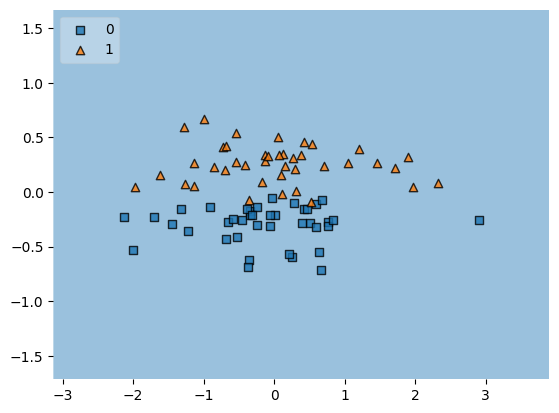

In [35]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(x_train, y_train, clf=model, legend=2)

Case where the constant values are initialized == same results